# DBSCAN con el dataset NYPD Arrest Data

Completa las celdas para aplicar **DBSCAN** a este dataset real del NYPD.

## Pasos
- Preparar el dataset.
- Seleccionar las variables adecuadas.
- Escalar los datos.
- Aplicar DBSCAN.
- Interpretar los clusters y el ruido.
>**Nota**: Las celdas que contiene el NOtebook son orientativas. Puedes modificarlas si fuese necesario en tu desarrollo.

In [57]:
# Si tu entorno no tiene instaladas estas librerías, descomenta la línea siguiente:
# !pip install pandas numpy matplotlib scikit-learn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

## 1. Carga del dataset

In [58]:
ruta = 'NYPD_Arrest_Data__Year_to_Date_.csv'
# Completa la lectura del CSV
# df = ...
df_vandalism = pd.read_csv(ruta)

# Muestra sus dimensiones y las primeras filas
df_vandalism.shape, 
df_vandalism.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


## 2. Exploración inicial

In [59]:
df_vandalism['PD_DESC'].value_counts()

PD_DESC
ASSAULT 3                         29405
LARCENY,PETIT FROM OPEN AREAS,    27698
ASSAULT 2,1,UNCLASSIFIED          15745
THEFT OF SERVICES, UNCLASSIFIE    15307
TRAFFIC,UNCLASSIFIED MISDEMEAN    14691
                                  ...  
SODOMY 3                              1
LOITERING,TRANSPORTATION FACIL        1
PERJURY 2,1,ETC                       1
AGRICULTURE & MARKETS LAW,UNCL        1
PROSTITUTION 2, UNDER 16              1
Name: count, Length: 262, dtype: int64

In [60]:
# Muestra los nombres de las columnas
print(df_vandalism.columns)

# Comprueba si hay valores nulos en Latitude y Longitude
df_vandalism[['Latitude', 'Longitude']].isnull().sum()

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')


Latitude     0
Longitude    0
dtype: int64

## 3. Selección de variables

Vas a trabajar con variables que estimes que pueden ser útiles en **DBSCAN**.

In [61]:
#Quiero filtrar por un tipo de delito concreto
df_vandalism = df_vandalism[(df_vandalism['PD_DESC'] == 'LARCENY,PETIT FROM OPEN AREAS,') | (df_vandalism['PERP_SEX'] == 'BLACK')]
df_vandalism.head()


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
58,299503943,01/15/2025,339,"LARCENY,PETIT FROM OPEN AREAS,",341.0,PETIT LARCENY,PL 1552500,M,M,19,0,(null),(null),WHITE HISPANIC,994836,219126,40.768130,-73.961782,POINT (-73.961782 40.76813)
71,298821081,01/02/2025,339,"LARCENY,PETIT FROM OPEN AREAS,",341.0,PETIT LARCENY,PL 1552500,M,Q,105,0,(null),(null),ASIAN / PACIFIC ISLANDER,1057766,203992,40.726292,-73.734762,POINT (-73.734762 40.726292)
87,299579967,01/16/2025,339,"LARCENY,PETIT FROM OPEN AREAS,",341.0,PETIT LARCENY,PL 1552500,M,M,24,0,45-64,M,BLACK,993372,229301,40.796058,-73.967054,POINT (-73.967054 40.796058)
96,300059014,01/26/2025,339,"LARCENY,PETIT FROM OPEN AREAS,",341.0,PETIT LARCENY,PL 1552500,M,B,40,0,(null),(null),WHITE HISPANIC,1008000,236675,40.816262,-73.914197,POINT (-73.91419711797286 40.816261945876654)
100,298808085,01/02/2025,339,"LARCENY,PETIT FROM OPEN AREAS,",341.0,PETIT LARCENY,PL 1552500,M,B,52,0,25-44,M,WHITE HISPANIC,1009475,257692,40.873953,-73.908789,POINT (-73.908789 40.873953)


In [62]:
# # df_vandalism["AGE_NUM"] = df_vandalism["AGE_GROUP"].map({
# #     "<18": 17,
# #     "18-24": 21,
# #     "25-44": 34.5,
# #     "45-64": 54.5,
# #     "65+": 70
# # })

# # Crea un nuevo DataFrame con las variables decididas
datos = df_vandalism[['Latitude', 'Longitude']]

# # Elimina los valores nulos
datos = datos.dropna()

# # Muestra cuántos registros quedan
datos.shape

(27698, 2)

## 4. Toma una muestra

In [63]:
# Toma una muestra aleatoria de 15000 -te recomiendo que al finalizar hagas otras pruebas- registros con random_state=42
muestra = datos.sample(n=12000, random_state=42)

# Muestra su tamaño
muestra.shape

(12000, 2)

## 5. Visualización inicial

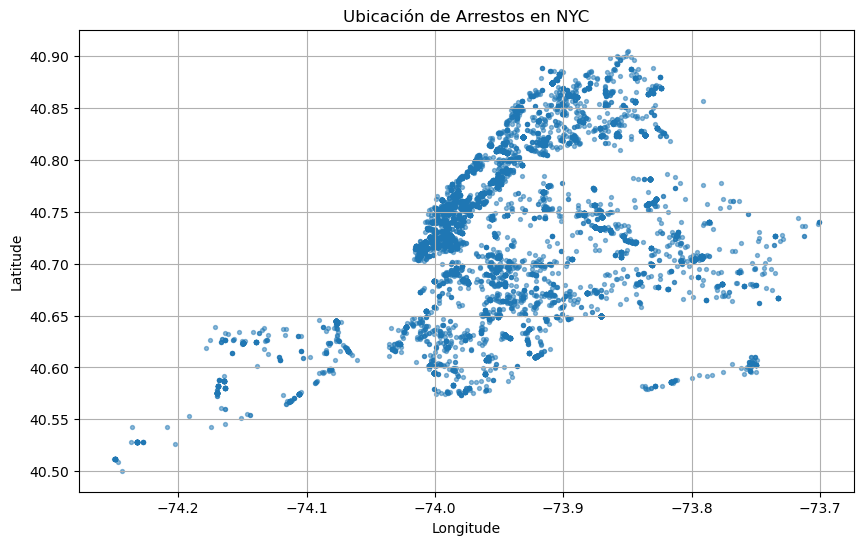

In [64]:
# Dibuja un scatter plot con:
# eje X -> Tu elección
# eje Y -> Tu elección
# tamaño pequeño de punto y cierta transparencia
plt.figure(figsize=(10,6))
plt.scatter(muestra['Longitude'], muestra['Latitude'], s=8, alpha=0.5)
plt.title('Ubicación de Arrestos en NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.show()

## 6. Escalado

In [65]:
# Crea el escalador
scaler = StandardScaler()

# Escala la muestra
X_scaled = scaler.fit_transform(muestra[['Longitude', 'Latitude']])

# Muestra las primeras filas escaladas
X_scaled[:5]

array([[-0.67340804, -0.21154243],
       [-0.4213212 , -0.63537318],
       [ 0.37588636,  1.15368138],
       [-0.57104036,  0.21421275],
       [-2.82332212, -1.94447918]])

## 7. Orientación para elegir eps

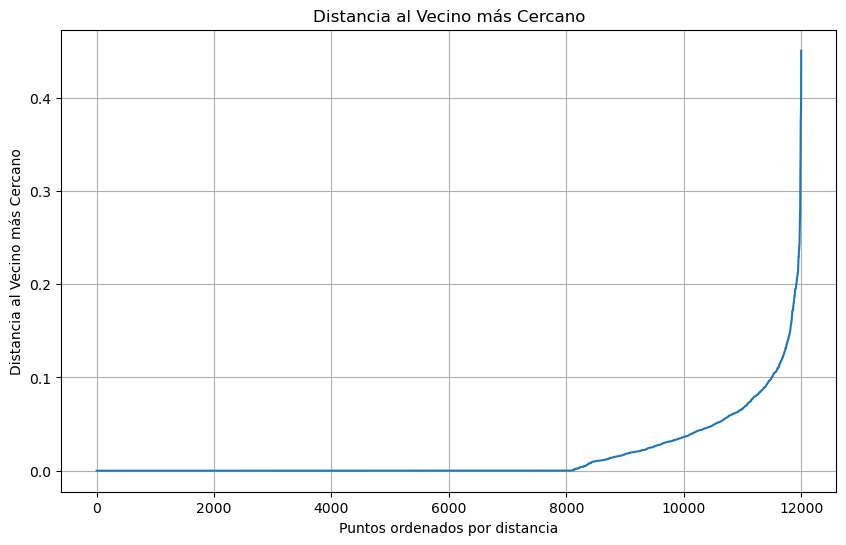

In [66]:
min_samples = 10

# Calcula los vecinos más cercanos
vecinos = NearestNeighbors(n_neighbors=min_samples)
vecinos.fit(X_scaled)

# Obtén las distancias
distancias, indices = vecinos.kneighbors(X_scaled)

# Quédate con la distancia al vecino número min_samples
distancias_ordenadas = np.sort(distancias[:, -1])

# Ordénalas y represéntalas
plt.figure(figsize=(10,6))
plt.plot(distancias_ordenadas)
plt.title('Distancia al Vecino más Cercano')
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel('Distancia al Vecino más Cercano')
plt.grid()
plt.show()

## 8. Aplicación de DBSCAN

In [67]:
# Crea el modelo DBSCAN con un eps inicial razonable (no olvides justificar)
modelo = DBSCAN(eps=0.3, min_samples=min_samples)

# Entrena el modelo y obtén las etiquetas
clusters = modelo.fit_predict(X_scaled)

# Añade la columna cluster a la muestra
muestra['cluster'] = clusters

In [68]:
# Calcula:
# - número de clusters (sin contar el ruido)
# - número de puntos ruido
# - tamaño de cada etiqueta
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_ruido = list(clusters).count(-1)
tamaño_clusters = pd.Series(clusters).value_counts()
print(f'Número de clusters: {n_clusters}')
print(f'Número de puntos ruido: {n_ruido}')
print('Tamaño de cada etiqueta:')
print(tamaño_clusters)

Número de clusters: 5
Número de puntos ruido: 4
Tamaño de cada etiqueta:
 0    11231
 2      453
 1      143
 3      103
 4       66
-1        4
Name: count, dtype: int64


## 9. Visualización final

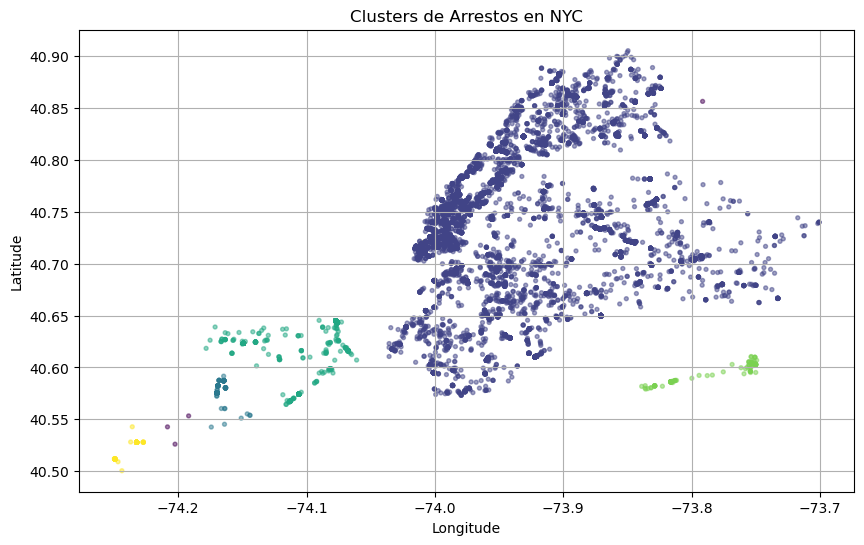

In [69]:
# Representa los puntos preferentemente en distinto color según el cluster encontrado
plt.figure(figsize=(10,6))
plt.scatter(muestra['Longitude'], muestra['Latitude'], c=muestra['cluster'], cmap='viridis', s=8, alpha=0.5)
plt.title('Clusters de Arrestos en NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.grid()
plt.show()

## 10. Interpretación

Responde brevemente:

1. ¿Qué significa la etiqueta `-1`?
- La etiqueta -1 equivale al ruido, que son los puntos que no podemos meter en un cluster debido a la distancia, por lo que como les damos el -1 para identificarlos como punto sin grupo

2. ¿Por qué DBSCAN puede detectar ruido y K-Means no?
- Porque kmeans busca si o si incluir todos los puntos en el número de grupos que se le indican, en cambio, DBSCAN utiliza como requisito la distancia entre puntos, por lo que si un punto no cumple ese requisito, además de la densidad de la zona, no le encuentra un grupo y lo deja como outlier

3. ¿Qué pasa si `eps` es demasiado pequeño?
- En caso de que epsilon sea muy pequeña, hace una cantidad de clusters absurda, por ejemplo, en este ejercicio probé con 0.1 y me encontró más de 15 grupos.

4. ¿Qué pasa si `eps` es demasiado grande?
- En este caso, si el epsilon es muy grande seguramente todos los puntos cumplan el requisito de distancia, por lo que solo encontrarás un único cluster.

5. ¿Por qué este dataset es más adecuado para DBSCAN que otros más simples?
- Porque ahora mismo estamos trabajando con datos geográficos de latitud y longitud, por lo que según lo comentado es bastante óptimo.

## 11. Opcional

Prueba una de estas ampliaciones:
- Compara con K-Means.
- Usa una muestra más grande.
- Analiza sólo un tipo de delito.

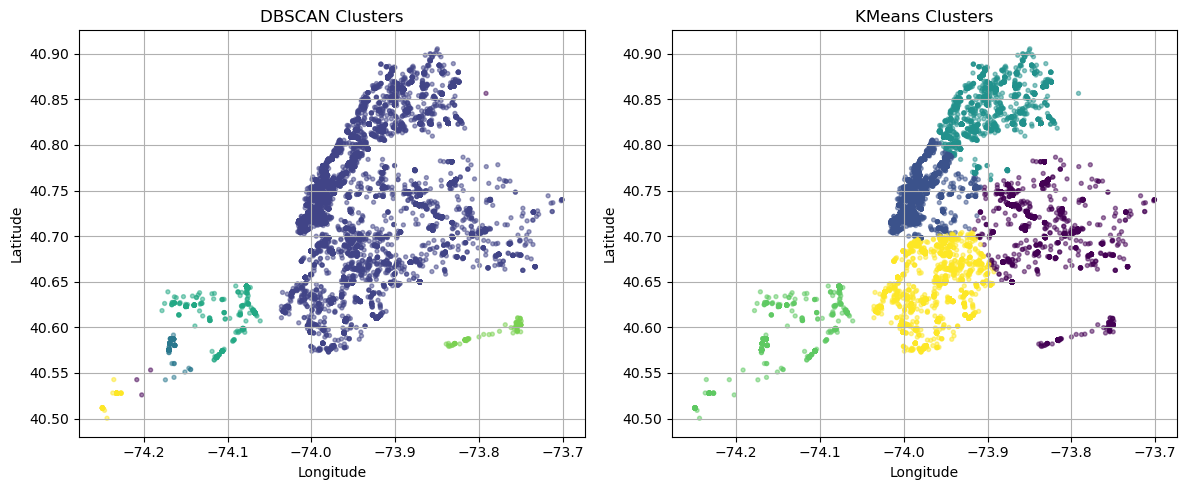

In [70]:
# Comparación grafica de DBSCAN y KMeans
from sklearn.cluster import KMeans
modelo_kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters_kmeans = modelo_kmeans.fit_predict(X_scaled)
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.scatter(muestra['Longitude'], muestra['Latitude'], c=muestra['cluster'], cmap='viridis', s=8, alpha=0.5)
plt.title('DBSCAN Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.subplot(1, 2, 2)
plt.scatter(muestra['Longitude'], muestra['Latitude'], c=clusters_kmeans, cmap='viridis', s=8, alpha=0.5)
plt.title('KMeans Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()
